In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("all ok")

all ok


In [7]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])


In [8]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["label"].value_counts())

Dataset Shape: (5572, 2)

Missing Values:
label      0
message    0
dtype: int64

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [10]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

X = df["message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [11]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (4457, 5000)
TF-IDF Testing Shape: (1115, 5000)


In [12]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9713004484304932

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9695067264573991

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



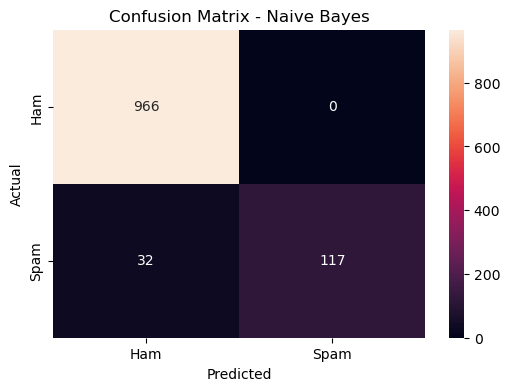

In [14]:
cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [15]:
results = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy
0,Multinomial Naive Bayes,0.971300
1,Logistic Regression,0.969507


In [17]:
new_messages = [
    "Congratulations! You have won a free lottery ticket. Call now!",
    "Hey, are we meeting for lunch today?"
]

new_tfidf = tfidf.transform(new_messages)
predictions = nb.predict(new_tfidf)

for message, prediction in zip(new_messages, predictions):
    result = "SPAM" if prediction == 1 else "HAM"
    print(f"{result}: {message}")

HAM: Congratulations! You have won a free lottery ticket. Call now!
HAM: Hey, are we meeting for lunch today?


Conclusion

In this project, a machine learning-based system was developed to classify messages as Spam or Ham. The text data was preprocessed and converted into numerical features using TF-IDF. Multinomial Naive Bayes and Logistic Regression were trained and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The results show that machine learning and NLP techniques can effectively identify spam messages. The best-performing model can be used as a basic automated spam detection system for filtering unwanted messages.